# 06 — Construction d'Équipe Optimale

> **Objectif** : calculer un score composite multi-critères, construire l'équipe optimale via un algorithme greedy et visualiser les résultats.

**Prérequis** : avoir exécuté `01_chargement_nettoyage.ipynb` et `05_efficacites_types.ipynb`

| Critère | Poids | Description |
|---|---|---|
| BST normalisé | 40% | Puissance brute globale |
| Score défensif | 25% | Résistances & immunités réelles |
| Couverture offensive STAB | 20% | Types frappés super efficacement |
| Équilibre des stats | 15% | Polyvalence vs hyper-spécialisation |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
from math import pi

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F5F6FA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

STATS = ['hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed']
TYPE_COLORS = {
    'normal': '#A8A878', 'fire': '#F08030', 'water': '#6890F0', 'electric': '#F8D030',
    'grass': '#78C850', 'ice': '#98D8D8', 'fighting': '#C03028', 'poison': '#A040A0',
    'ground': '#E0C068', 'flying': '#A890F0', 'psychic': '#F85888', 'bug': '#A8B820',
    'rock': '#B8A038', 'ghost': '#705898', 'dragon': '#7038F8', 'dark': '#705848',
    'steel': '#B8B8D0', 'fairy': '#EE99AC', 'stellar': '#40B5A5',
}
TEAM_COLORS = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C']

with open('../data/pokemon_full.pkl', 'rb') as f:
    data = pickle.load(f)
df, matrix, ALL_TYPES = data['df'], data['matrix'], data['ALL_TYPES']
print(f'Données chargées : {df.shape[0]} Pokémon')

Données chargées : 1025 Pokémon


## 1. Score composite multi-critères


In [ ]:
def normalize(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn) if mx != mn else series * 0

df['stat_std']  = df[STATS].std(axis=1)
df['stat_mean'] = df[STATS].mean(axis=1)
df['balance']   = 1 - normalize(df['stat_std'] / df['stat_mean'])

df['bst_norm']  = normalize(df['bst'])
df['def_norm']  = normalize(df['defense_score'])
df['off_norm']  = normalize(df['n_offense'])
df['composite'] = (0.40 * df['bst_norm']
                 + 0.25 * df['def_norm']
                 + 0.20 * df['off_norm']
                 + 0.15 * df['balance'])

print('Score composite calculé')
display(df[['name','type1','type2','bst','defense_score','n_offense','balance','composite']]
        .nlargest(10, 'composite')
        .assign(name=lambda d: d['name'].str.capitalize())
        .round(3).reset_index(drop=True))

Score composite calculé


,name,type1,type2,bst,defense_score,n_offense,balance,composite
0,Magearna,steel,fairy,600,11,6,0.818,0.818
1,Dialga,steel,dragon,680,9,4,0.858,0.805
2,Solgaleo,psychic,steel,680,7,5,0.868,0.795
3,Genesect,bug,steel,600,9,6,0.863,0.791
4,Celesteela,steel,flying,570,10,6,0.867,0.787
5,Heatran,fire,steel,600,8,6,0.863,0.775
6,Iron-treads,ground,steel,570,8,7,0.835,0.771
7,Landorus-incarnate,ground,flying,600,5,8,0.872,0.771
8,Tinkaton,fairy,steel,506,11,6,0.884,0.759
9,Gholdengo,steel,ghost,550,11,5,0.808,0.757


## 2. Top 15 Pokémon — Score composite


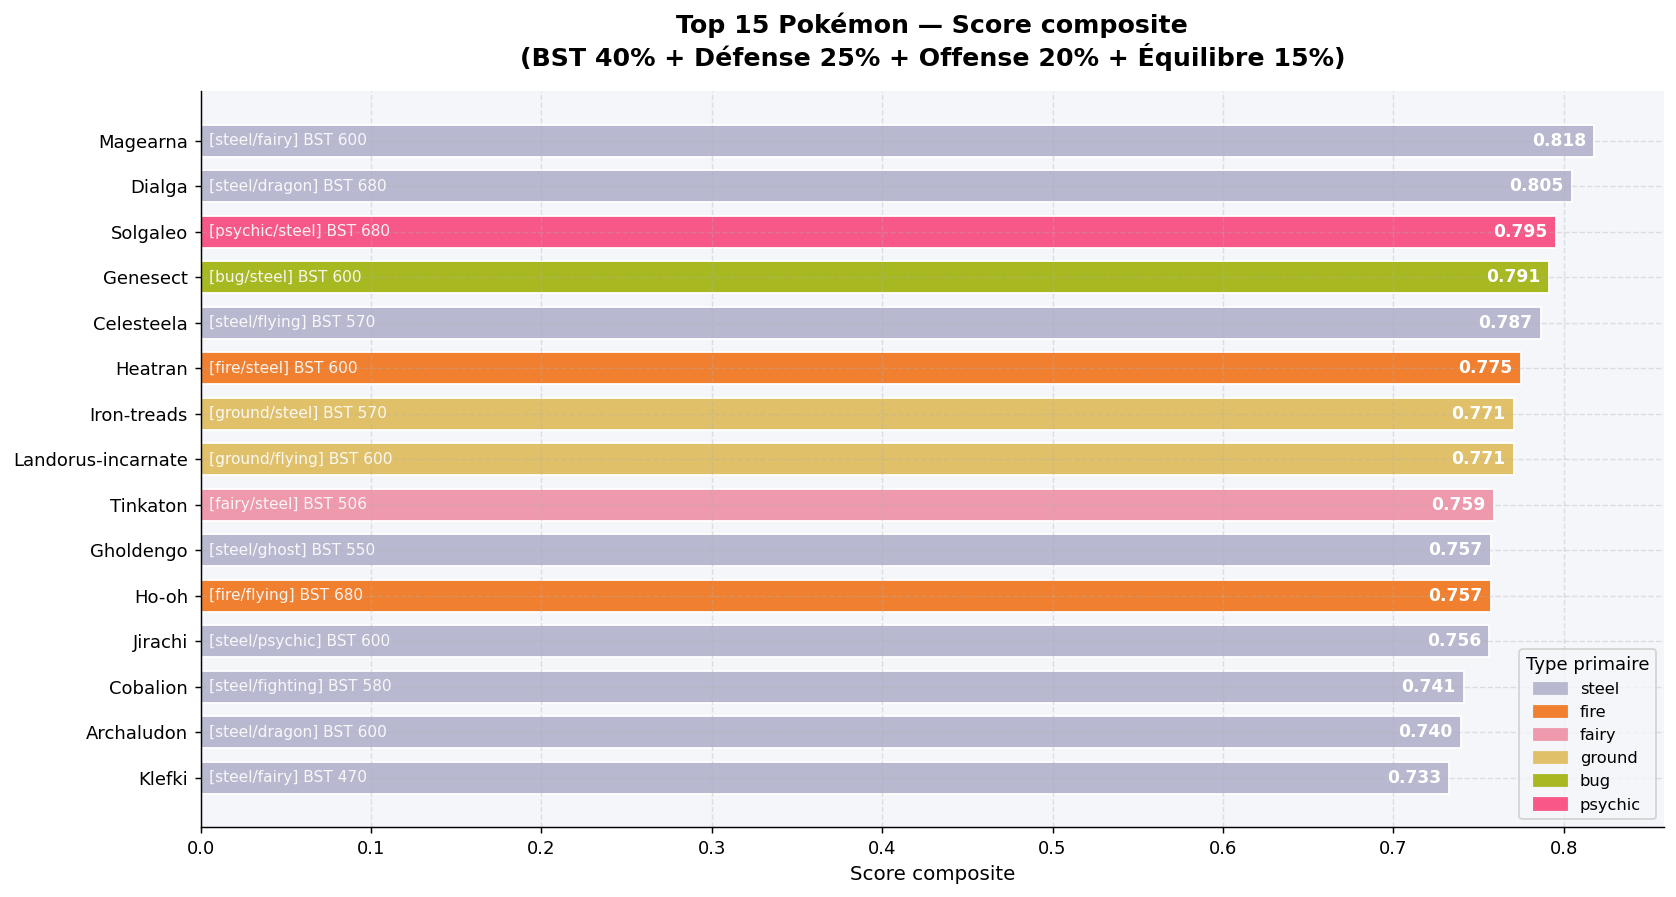

In [ ]:
top15 = df.nlargest(15, 'composite').copy()
top15['name'] = top15['name'].str.capitalize()
top15 = top15.sort_values('composite')

fig, ax = plt.subplots(figsize=(13, 7))
bar_colors = [TYPE_COLORS.get(t, '#888') for t in top15['type1']]
bars = ax.barh(top15['name'], top15['composite'],
               color=bar_colors, edgecolor='white', linewidth=1, height=0.7)

for bar, (_, row) in zip(bars, top15.iterrows()):
    ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
            f'{row["composite"]:.3f}', va='center', ha='right',
            fontsize=9.5, color='white', fontweight='bold')
    type_str = row['type1'] if pd.isna(row['type2']) else f"{row['type1']}/{row['type2']}"
    ax.text(0.005, bar.get_y() + bar.get_height()/2,
            f'[{type_str}] BST {int(row["bst"])}',
            va='center', fontsize=8.5, color='white', alpha=0.9)

ax.set_title('Top 15 Pokémon — Score composite\n(BST 40% + Défense 25% + Offense 20% + Équilibre 15%)', pad=14)
ax.set_xlabel('Score composite')

handles = [mpatches.Patch(color=TYPE_COLORS.get(t,'#888'), label=t)
           for t in top15['type1'].unique()]
ax.legend(handles=handles, title='Type primaire', loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Algorithme greedy — Construction de l'équipe

> À chaque étape, on sélectionne le Pokémon qui maximise le score composite **ajusté** par :
- La couverture des **faiblesses défensives** actuelles de l'équipe
- Le comblement des **angles morts offensifs**


In [ ]:
def build_team(pool, size=6):
    team, team_def_profiles = [], []
    team_off_covered = set()

    first = pool.iloc[0]
    team.append(first)
    team_def_profiles.append(first['defense_profile'])
    team_off_covered.update(first['offense_coverage'])
    remaining = pool.iloc[1:].copy()

    while len(team) < size and len(remaining) > 0:
        team_weaknesses = {t for p in team_def_profiles for t, v in p.items() if v > 1}
        off_gaps = set(ALL_TYPES) - team_off_covered

        def candidate_score(row):
            def_cover = sum(1 for t in team_weaknesses if row['defense_profile'].get(t, 1) <= 1)
            off_cover = len(row['offense_coverage'] & off_gaps)
            return row['composite'] + 0.12 * def_cover + 0.08 * off_cover

        best_idx = remaining.apply(candidate_score, axis=1).idxmax()
        best     = remaining.loc[best_idx]
        team.append(best)
        team_def_profiles.append(best['defense_profile'])
        team_off_covered.update(best['offense_coverage'])
        remaining = remaining.drop(best_idx)

    return pd.DataFrame(team)

pool    = df.nlargest(150, 'composite').reset_index(drop=True)
team_df = build_team(pool)

print('Équipe optimale sélectionnée :')
display(team_df[['name','type1','type2','bst','defense_score','n_offense','balance','composite']]
        .assign(name=lambda d: d['name'].str.capitalize())
        .round(3).reset_index(drop=True))

off_covered = set()
for cov in team_df['offense_coverage']:
    off_covered.update(cov)
print(f'\nCouverture offensive : {len(off_covered)}/{len(ALL_TYPES)} types à 2×')
missing = sorted(set(ALL_TYPES) - off_covered)

Équipe optimale sélectionnée :


,name,type1,type2,bst,defense_score,n_offense,balance,composite
0,Magearna,steel,fairy,600,11,6,0.818,0.818
1,Landorus-incarnate,ground,flying,600,5,8,0.872,0.771
2,Marshadow,fighting,ghost,600,3,7,0.853,0.712
3,Tapu-fini,water,fairy,570,5,6,0.816,0.696
4,Zapdos,electric,flying,580,5,5,0.887,0.691
5,Dialga,steel,dragon,680,9,4,0.858,0.805



Couverture offensive : 18/19 types à 2×


## 4. Radar des statistiques de l'équipe


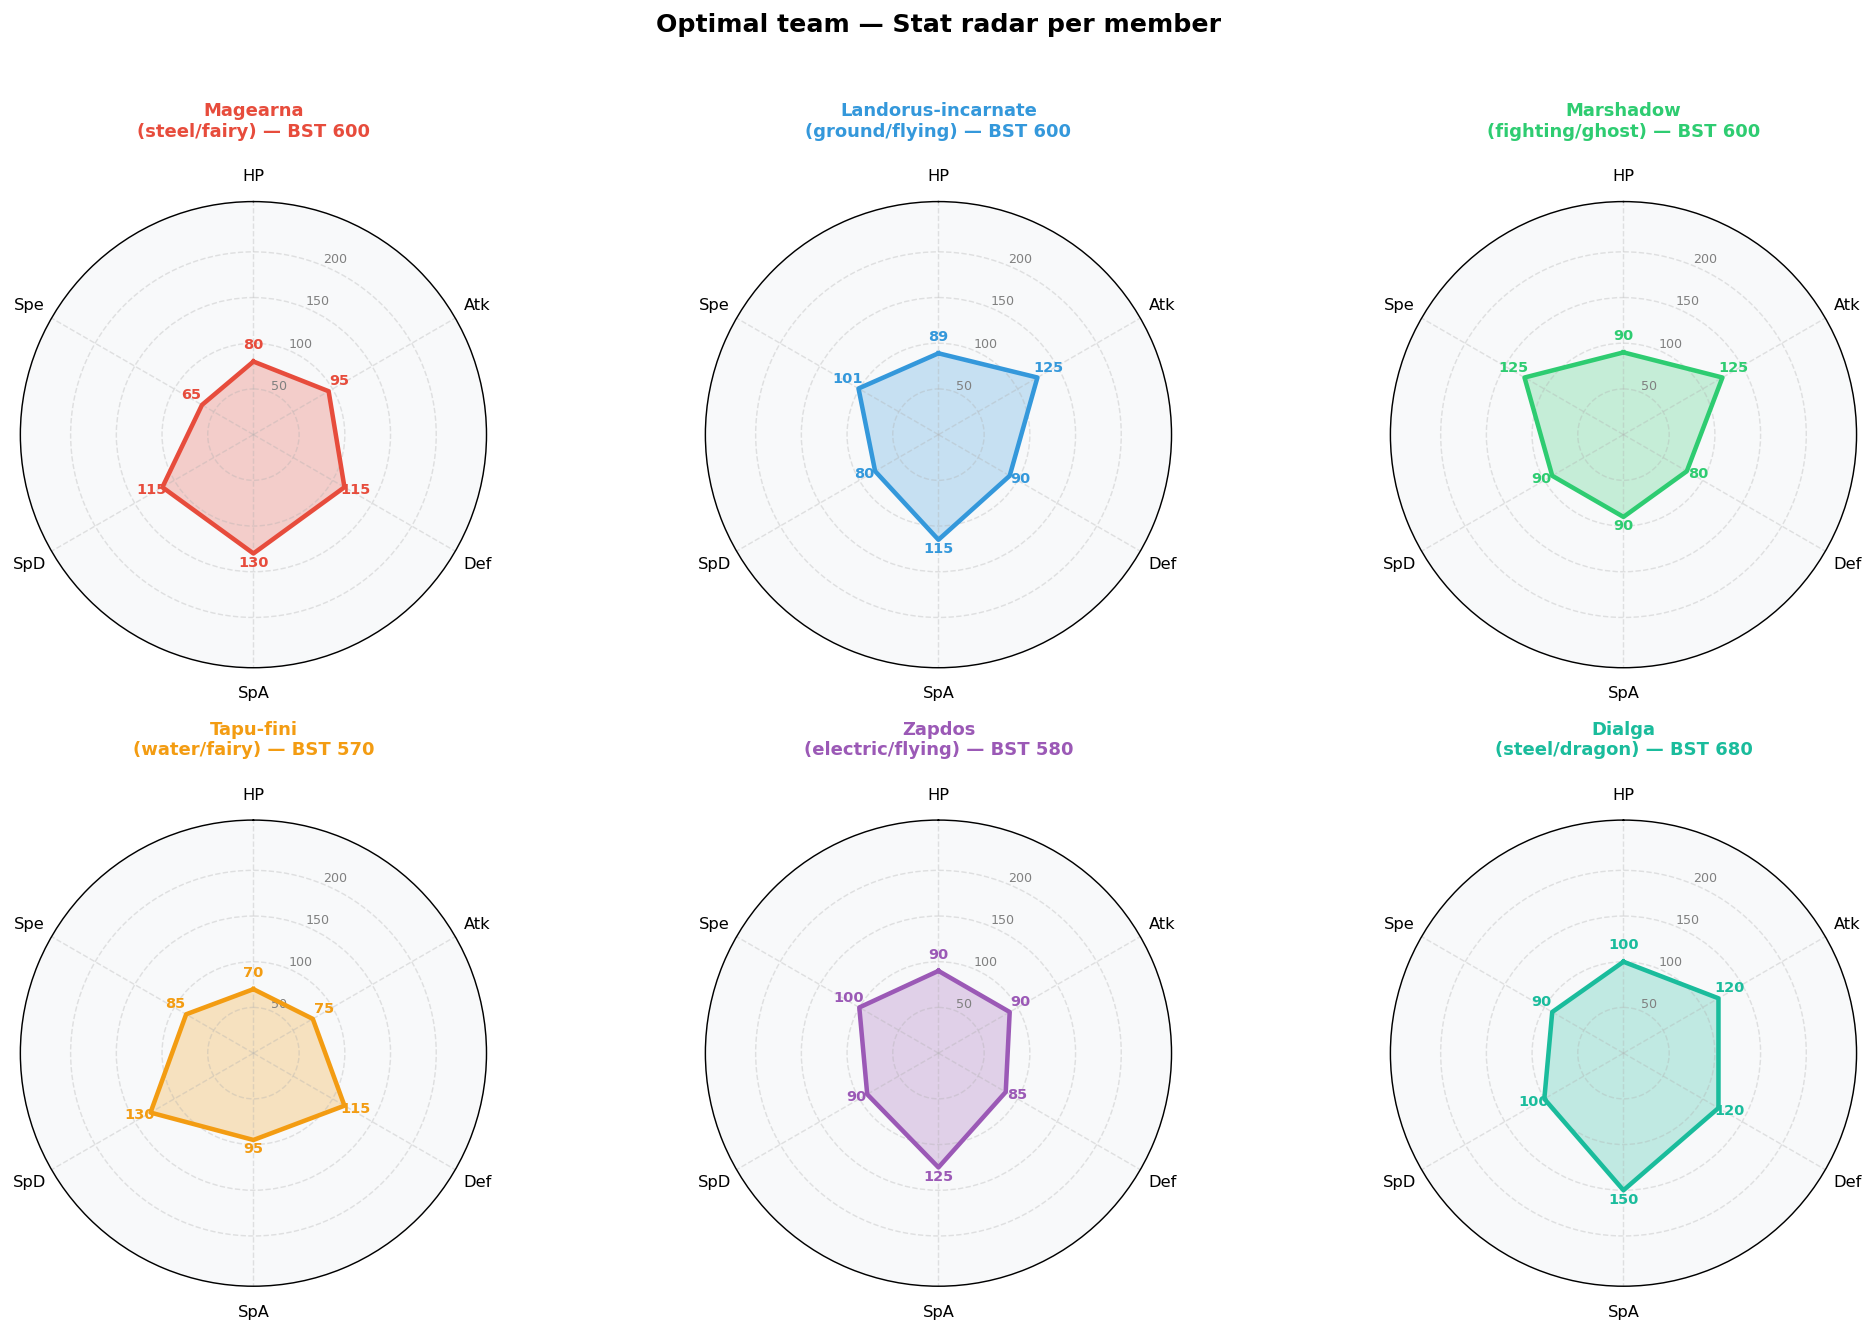

In [ ]:
radar_labels = ['HP', 'Atk', 'Def', 'SpA', 'SpD', 'Spe']
N = len(STATS)
angles = [n / float(N) * 2 * pi for n in range(N)] 

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('white')

for idx, ((_, row), color) in enumerate(zip(team_df.iterrows(), TEAM_COLORS)):
    ax = fig.add_subplot(2, 3, idx + 1, polar=True)
    vals = [row[s] for s in STATS]      
    angles_plot = angles + [angles[0]] 
    vals_plot   = vals   + [vals[0]] 

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels(radar_labels, size=9)
    ax.set_ylim(0, 255)
    ax.set_yticks([50, 100, 150, 200])
    ax.set_yticklabels(['50', '100', '150', '200'], size=7, color='grey')
    ax.set_facecolor('#F8F9FA')

    ax.plot(angles_plot, vals_plot, color=color, linewidth=2.5)
    ax.fill(angles_plot, vals_plot, color=color, alpha=0.25)

    for angle, val in zip(angles, vals):
        ax.annotate(str(val), xy=(angle, val), xytext=(angle, val + 14),
                    ha='center', fontsize=8, color=color, fontweight='bold')

    type_info = row['type1'] if pd.isna(row['type2']) else f"{row['type1']}/{row['type2']}"
    ax.set_title(
        f"{row['name'].capitalize()}\n({type_info}) — BST {int(row['bst'])}",
        size=10, fontweight='bold', pad=18, color=color
    )

plt.suptitle('Optimal team — Stat radar per member', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Profil défensif de l'équipe


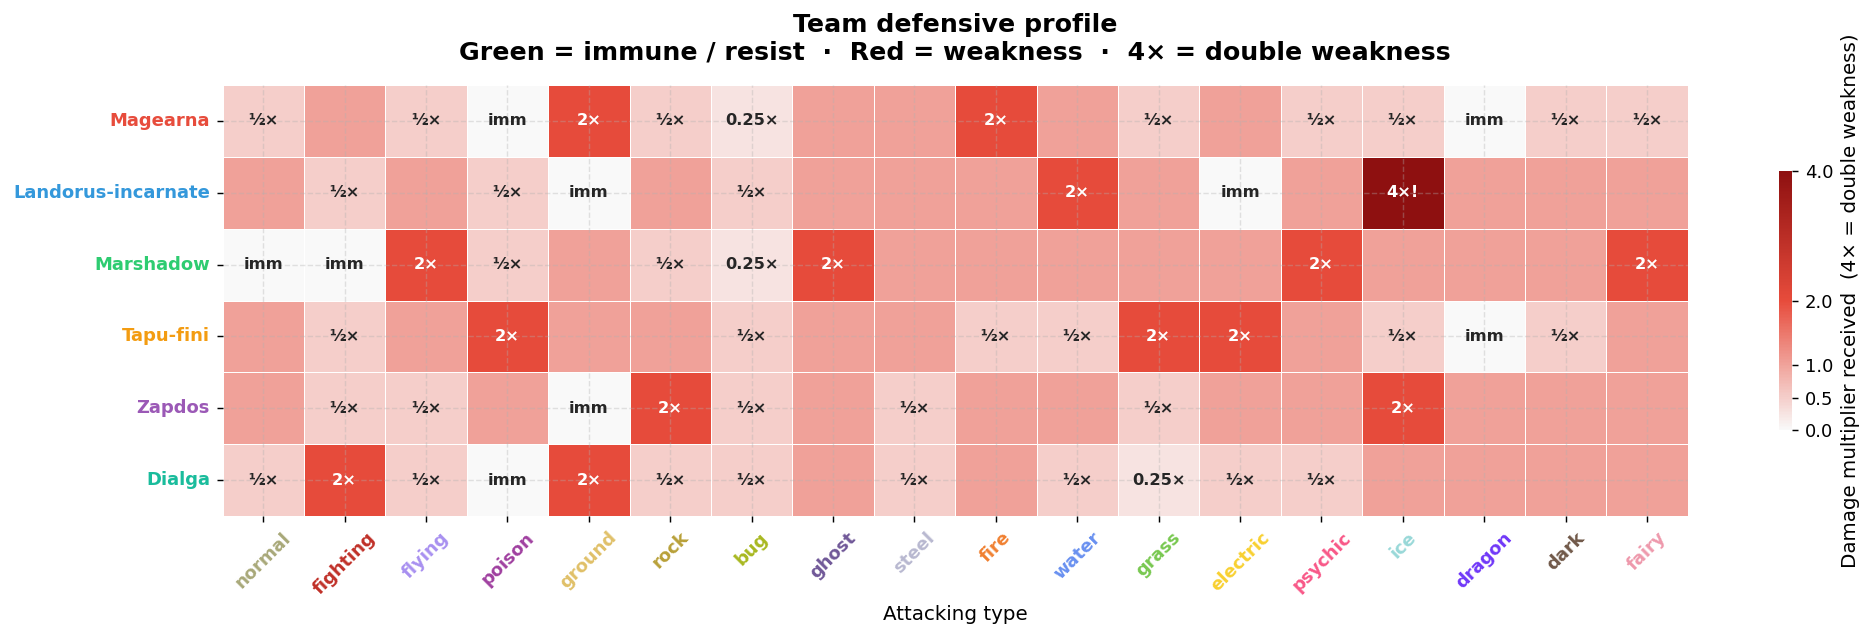

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
cmap_team = LinearSegmentedColormap.from_list(
    'team_def', ['#2ECC71', '#F9F9F9', '#E74C3C', '#8E1010'], N=256
)

team_names = [row['name'].capitalize() for _, row in team_df.iterrows()]
display_types = [t for t in ALL_TYPES if t != 'stellar']

team_weak = pd.DataFrame(
    [{t: row['defense_profile'].get(t, 1.0) for t in display_types}
     for _, row in team_df.iterrows()],
    index=team_names
)

def fmt_team(v):
    if v == 0:   return 'imm'
    if v == 0.5: return '½×'
    if v == 1:   return ''
    if v == 2:   return '2×'
    if v == 4:   return '4×!'
    return f'{v}×'

annot_team = team_weak.map(fmt_team)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    team_weak,
    annot=annot_team, fmt='',
    cmap=cmap_team,
    center=1, vmin=0, vmax=4,
    linewidths=0.5, linecolor='white',
    ax=ax,
    annot_kws={'size': 9, 'weight': 'bold'},
    cbar_kws={
        'shrink': 0.6,
        'label': 'Damage multiplier received  (4× = double weakness)',
        'ticks': [0, 0.5, 1, 2, 4]
    }
)
ax.set_title(
    "Team defensive profile\nGreen = immune / resist  ·  Red = weakness  ·  4× = double weakness",
    pad=14
)
ax.set_xlabel('Attacking type')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

for i, t in enumerate(display_types):
    ax.get_xticklabels()[i].set_color(TYPE_COLORS.get(t, '#333'))
    ax.get_xticklabels()[i].set_fontweight('bold')
for label, color in zip(ax.get_yticklabels(), TEAM_COLORS):
    label.set_color(color)
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()

## 6. Couverture offensive de l'équipe


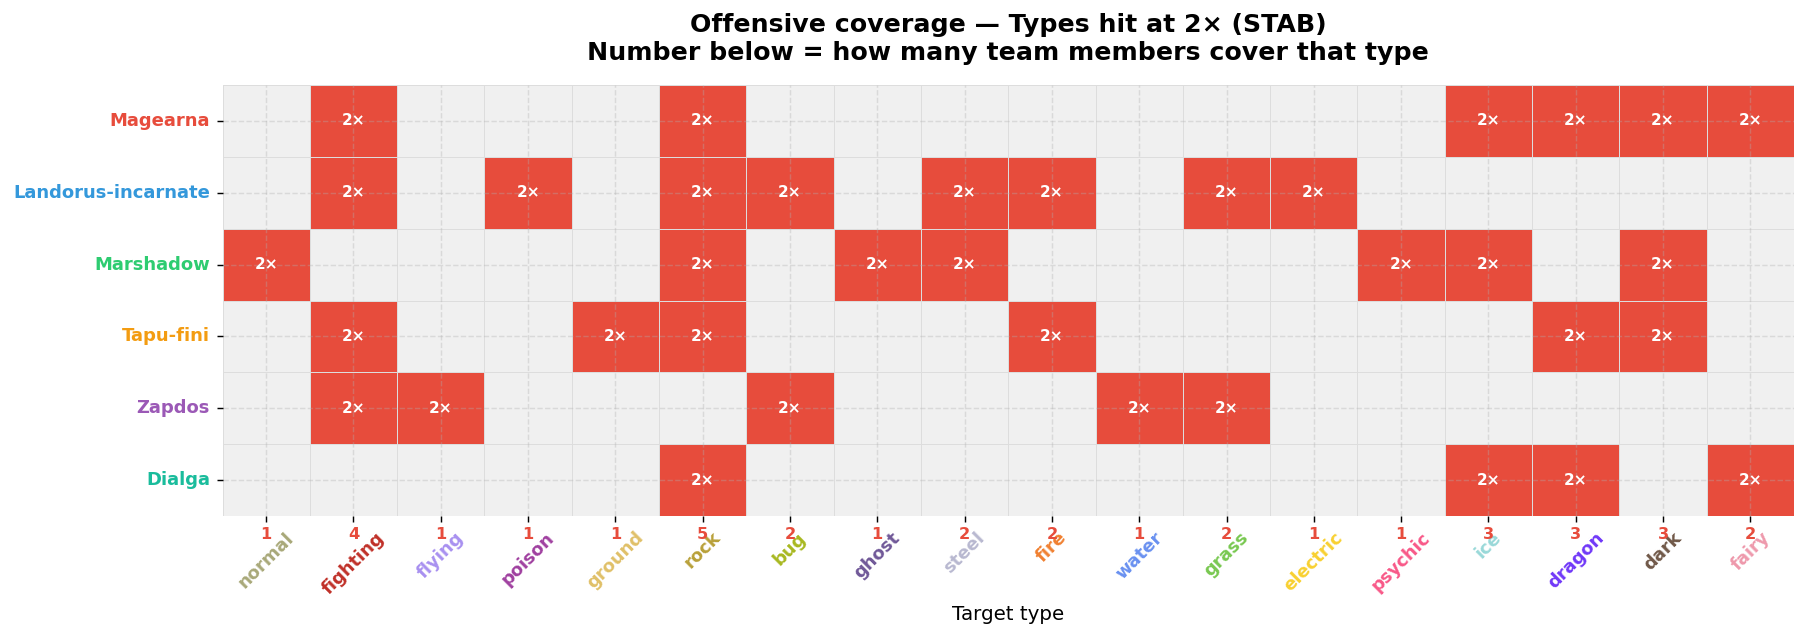

Offensive coverage: 18/18 types hit at 2×


In [ ]:
display_types = [t for t in ALL_TYPES if t != 'stellar']
team_names = [row['name'].capitalize() for _, row in team_df.iterrows()]

coverage_matrix = pd.DataFrame(
    0, index=team_names, columns=display_types
)
for _, row in team_df.iterrows():
    name = row['name'].capitalize()
    for t in row['offense_coverage']:
        if t in display_types:
            coverage_matrix.loc[name, t] = 2

cmap_off = LinearSegmentedColormap.from_list('off_cov', ['#F0F0F0', '#E74C3C'], N=3)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    coverage_matrix,
    annot=coverage_matrix.map(lambda v: '2×' if v == 2 else ''),
    fmt='',
    cmap=cmap_off,
    vmin=0, vmax=2,
    linewidths=0.4, linecolor='#ddd',
    ax=ax, cbar=False,
    annot_kws={'size': 8.5, 'weight': 'bold', 'color': 'white'}
)

for i, t in enumerate(display_types):
    total = (coverage_matrix[t] == 2).sum()
    color = '#E74C3C' if total > 0 else '#AAAAAA'
    ax.text(i + 0.5, len(team_df) + 0.15, str(total),
            ha='center', va='top', fontsize=9, fontweight='bold', color=color)

ax.set_title('Offensive coverage — Types hit at 2× (STAB)\nNumber below = how many team members cover that type', pad=14)
ax.set_xlabel('Target type')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

for label, color in zip(ax.get_yticklabels(), TEAM_COLORS):
    label.set_color(color)
    label.set_fontweight('bold')
for i, t in enumerate(display_types):
    ax.get_xticklabels()[i].set_color(TYPE_COLORS.get(t, '#333'))
    ax.get_xticklabels()[i].set_fontweight('bold')

plt.tight_layout()
plt.show()

all_covered = {t for _, row in team_df.iterrows() for t in row['offense_coverage'] if t != 'stellar'}
not_covered = sorted(set(display_types) - all_covered)
print(f'Offensive coverage: {len(all_covered)}/{len(display_types)} types hit at 2×')